      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
Shape: (15, 9)
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
            math    science    english    history         pe  attendance_pct  \
count  15.0

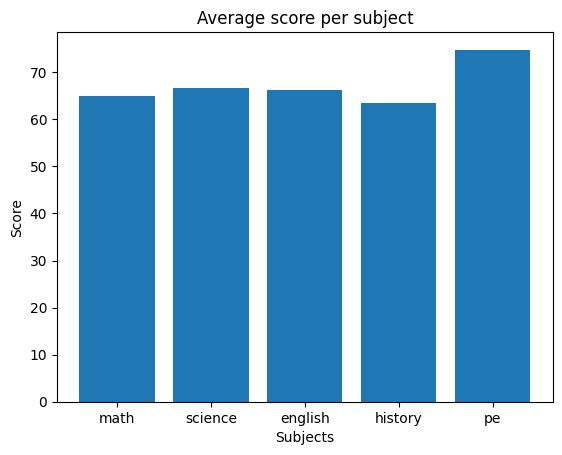

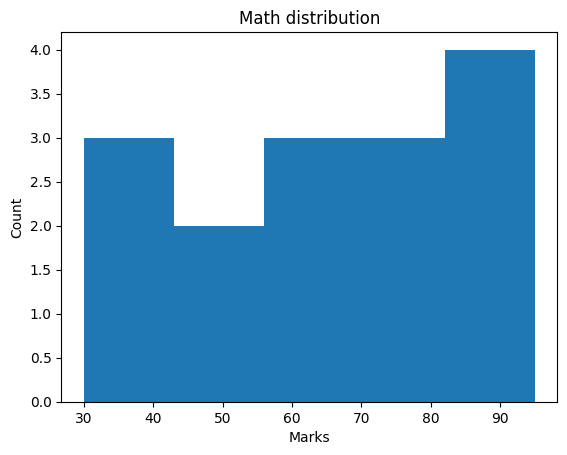

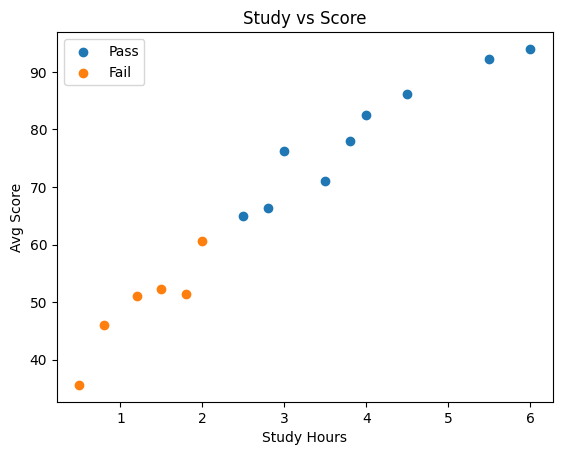

/tmp/ipykernel_3251/2524602841.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_data['attendance_pct'], fail_data['attendance_pct']], labels=["Pass", "Fail"])


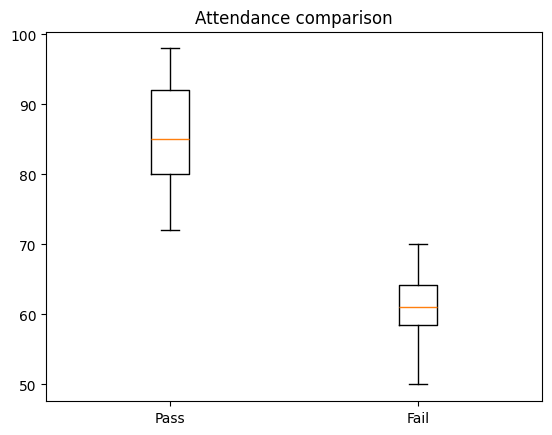

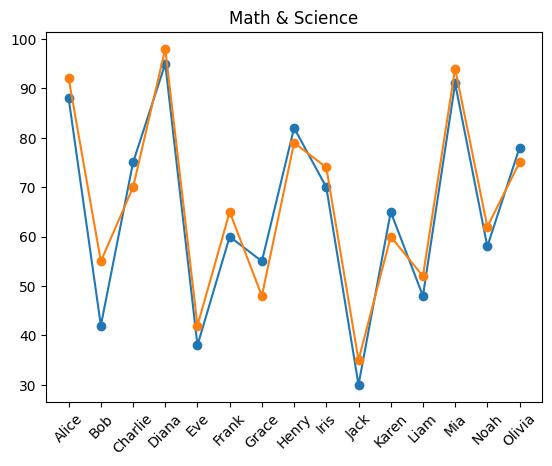

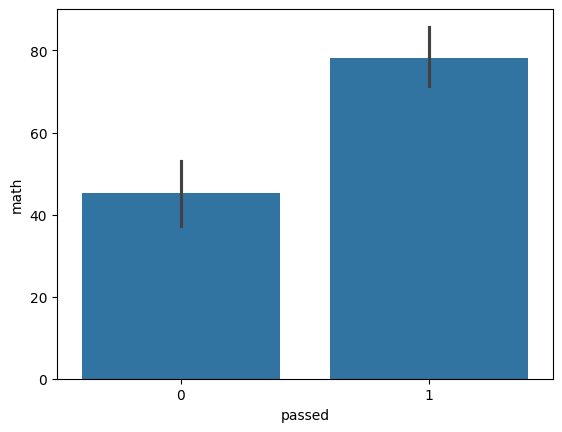

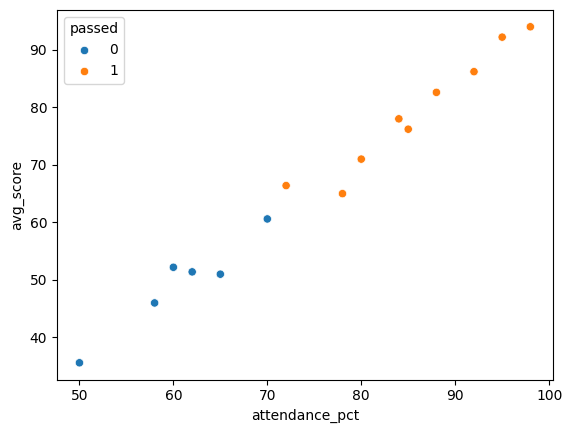

Train accuracy: 1.0
Test accuracy: 0.6666666666666666


AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("students.csv")

#task1
print(df.head())

print("Shape:", df.shape)
print(df.dtypes)

print(df.describe())

print(df['passed'].value_counts())

subjects = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage (Pass):")
print(df[df['passed'] == 1][subjects].mean())

print("\nAverage (Fail):")
print(df[df['passed'] == 0][subjects].mean())

df['avg'] = df[subjects].mean(axis=1)
top = df.loc[df['avg'].idxmax()]
print("\nTop student:", top['name'], top['avg'])

#task2

df['avg_score'] = df[subjects].mean(axis=1)

#1. BAR
plt.figure()
plt.bar(subjects, df[subjects].mean())
plt.title("Average score per subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()

#2. HISTOGRAM
plt.figure()
plt.hist(df['math'], bins=5)
plt.title("Math distribution")
plt.xlabel("Marks")
plt.ylabel("Count")
plt.savefig("plot2_hist.png")
plt.show()

#3. SCATTER
plt.figure()
pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.legend()
plt.xlabel("Study Hours")
plt.ylabel("Avg Score")
plt.title("Study vs Score")
plt.savefig("plot3_scatter.png")
plt.show()

#4. BOX
plt.figure()
plt.boxplot([pass_data['attendance_pct'], fail_data['attendance_pct']], labels=["Pass", "Fail"])
plt.title("Attendance comparison")
plt.savefig("plot4_box.png")
plt.show()

#5. LINE
plt.figure()
plt.plot(df['name'], df['math'], marker='o')
plt.plot(df['name'], df['science'], marker='o')
plt.xticks(rotation=45)
plt.title("Math & Science")
plt.savefig("plot5_line.png")
plt.show()

#task3

#seaborn bar
plt.figure()
sns.barplot(data=df, x='passed', y='math')
plt.savefig("plot6_seaborn_bar.png")
plt.show()

#seaborn scatter
plt.figure()
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

#seaborn is easier and looks better automatically
#matplotlib needs more manual work

#task4

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

pred = model.predict(X_test)

names = df.loc[X_test.index, 'name']

print("\nPredictions:")
for i in range(len(pred)):
    actual = y_test.iloc[i]
    predicted = pred[i]
    name = names.iloc[i]

    if actual == predicted:
        result = "Correct"
    else:
        result = "Wrong"

    print(name, "| Actual:", actual, "| Pred:", predicted, "|", result)

#feature importance
features = X.columns
coef = model.coef_[0]

print("\nFeature Importance:")
for i in range(len(features)):
    print(features[i], coef[i])

#bar chart
plt.figure()
plt.barh(features, coef)
plt.title("Feature importance")
plt.savefig("plot8_feature.png")
plt.show()

#bonus prediction
new_student = [[75,70,68,65,80,82,3.2]]
new_scaled = scaler.transform(new_student)

result = model.predict(new_scaled)
print("New student prediction:", result)